In [44]:
import matplotlib.pyplot as plt
import numpy as np
from numpy import log as ln
from numpy import log10 as log
from numpy import exp as exp
from scipy.optimize import dual_annealing
from scipy.optimize import minimize
from random import uniform, randint
from statistics import mean, stdev
import time
import os
import emcee
import corner
import math
import warnings
from multiprocessing.pool import Pool
from multiprocessing import get_start_method
from multiprocessing import get_context

In [45]:
# Create array of total pressures
# P is in Pascal but limits initially given in bar for convenience
P_min=1.0      #bar
P_max=4000.0  #bar
P_min=P_min*1.0e5  #Pascal
P_max=P_max*1.0e5  #Pascal
num=200
P=np.linspace(P_min,P_max,num)
# Convert P back to bar for plotting etc.
Pbar=P/1.0e5
PGPa=P/1.0e9  #GPa units

In [46]:
# VALUES CONTAIN ALL MODEL INPUT PARAMETERS IN ORDER
print('Opening Outgassing model initial.txt...')
name="Outgassing model initial.txt"
count = len(open(name).readlines())
print('  Input file length = ', count)
values=np.genfromtxt(name,'float')  # Read from file into values
print('')

Opening Outgassing model initial.txt...
  Input file length =  76



In [47]:
# Create an array of temperatures
T_min = 1300.0  #K
T_max = values[30] #K THIS DEFINES CORE-MANTLE BOUNDARY T, as T(num-1) or as T_max
TK=np.linspace(T_min,T_max,num)

In [49]:
#THERMODYNAMICS OF MELT REACTIONS
#
log_to_ln = 2.302585093
Rgas=8.314462618153
TKlength=len(TK)

In [50]:
#MgO melt (3105K-5000K)
# from NIST
ti=TK/1000.0
a=66.944
b=0.00
c=0.00
d=0.00
e=0.00
f=-580.9944
g=93.74712
h=-532.6106
HmeltMgO=-532.61+a*ti+(b*ti**2.0)/2.0+(c*ti**3.0)/3.0+(d*ti**4.0)/4.0-(e/ti)+f-h
HmeltMgO=HmeltMgO*1000.0 #convert kJ to J
SmeltMgO=a*ln(ti)+b*ti+(c*ti**2.0)/2.0+(d*ti**3.0)/3.0-(e/(2.0*ti**2.0))+g
GmeltMgO=HmeltMgO-TK*SmeltMgO  #apparent G of formation of MgO liquid at T and 1 bar

a_file = open('Gibbs free energy.txt', 'w')
a_file.write("Component")
a_file.write("")
a_file.write("  Temperature")
a_file.write("  A")
a_file.write("  B")
a_file.write("  C")
a_file.write("  D")
a_file.write("  E")
a_file.write("  F")
a_file.write("  G")
a_file.write("  H\n")
a_file.write("MgO melt")
a_file.write(" ")
a_file.write("3105K-5000K")
a_file.write(" ")
a_file.write("%10.5e " % a)
a_file.write("")
a_file.write("%10.5e " % b)
a_file.write("")
a_file.write("%10.5e " % c)
a_file.write("")
a_file.write("%10.5e " % d)
a_file.write("")
a_file.write("%10.5e " % e)
a_file.write("")
a_file.write("%10.5e " % f)
a_file.write("")
a_file.write("%10.5e " % g)
a_file.write("")
a_file.write("%10.5e\n" % h)
a_file.close()

In [51]:
#SiO2 melt (1996K-4500K)
# from NIST
ti=TK/1000.0
a=85.772
b=-0.000016
c=0.000004
d=-3.809081e-7
e=-0.000017
f=-952.87
g=113.344
h=-902.6610
HmeltSiO2=-902.661+a*ti+(b*ti**2.0)/2.0+(c*ti**3.0)/3.0+(d*ti**4.0)/4.0-(e/ti)+f-h
HmeltSiO2=HmeltSiO2*1000.0 #convert kJ to J
SmeltSiO2=a*ln(ti)+b*ti+(c*ti**2.0)/2.0+(d*ti**3.0)/3.0-(e/(2.0*ti**2.0))+g
GmeltSiO2=HmeltSiO2-TK*SmeltSiO2  #apparent G of formation of SiO2 melt at T and 1 bar
a_file = open('Gibbs free energy.txt', 'a')
a_file.write("SiO2 melt")
a_file.write(" ")
a_file.write("1996K-4500K")
a_file.write(" ")
a_file.write("%10.5e " % a)
a_file.write("")
a_file.write("%10.5e " % b)
a_file.write("")
a_file.write("%10.5e " % c)
a_file.write("")
a_file.write("%10.5e " % d)
a_file.write("")
a_file.write("%10.5e " % e)
a_file.write("")
a_file.write("%10.5e " % f)
a_file.write("")
a_file.write("%10.5e " % g)
a_file.write("")
a_file.write("%10.5e\n" % h)
a_file.close()

In [52]:
#MgSiO3 melt (1850K-3000K)
# from NIST
ti=TK/1000.0
a=146.440
b=-1.499926e-7
c=6.220145e-8
d=-8.733222e-09
e=-3.144171e-8
f=-1563.306
g=220.6679
h=-1494.864
HmeltMgSiO3=-1494.86+a*ti+(b*ti**2.0)/2.0+(c*ti**3.0)/3.0+(d*ti**4.0)/4.0-(e/ti)+f-h
HmeltMgSiO3=HmeltMgSiO3*1000.0 #convert kJ to J
SmeltMgSiO3=a*ln(ti)+b*ti+(c*ti**2.0)/2.0+(d*ti**3.0)/3.0-(e/(2.0*ti**2.0))+g
GmeltMgSiO3=HmeltMgSiO3-TK*SmeltMgSiO3  #apparent G of formation of MgO liquid at T and 1 bar
a_file = open('Gibbs free energy.txt', 'a')
a_file.write("MgSiO3 melt")
a_file.write(" ")
a_file.write("1850K-3000K")
a_file.write(" ")
a_file.write("%10.5e " % a)
a_file.write("")
a_file.write("%10.5e " % b)
a_file.write("")
a_file.write("%10.5e " % c)
a_file.write("")
a_file.write("%10.5e " % d)
a_file.write("")
a_file.write("%10.5e " % e)
a_file.write("")
a_file.write("%10.5e " % f)
a_file.write("")
a_file.write("%10.5e " % g)
a_file.write("")
a_file.write("%10.5e\n" % h)
a_file.close()

In [53]:
#FeO melt (1650K-5000K)
#from NIST
ti=TK/1000.0
a=68.19920
b=-4.501232e-10
c=1.195227e-10
d=-1.064302e-11
e=-3.09268e-10
f=-281.4326
g=137.8377
h=-249.5321
HmeltFeO=-249.5321+a*ti+(b*ti**2.0)/2.0+(c*ti**3.0)/3.0+(d*ti**4.0)/4.0-(e/ti)+f-h
HmeltFeO=HmeltFeO*1000.0 #convert kJ to J
SmeltFeO=a*ln(ti)+b*ti+(c*ti**2.0)/2.0+(d*ti**3.0)/3.0-(e/(2.0*ti**2.0))+g
GmeltFeO=HmeltFeO-TK*SmeltFeO  #apparent G of formation of FeO melt at T and 1 bar
a_file = open('Gibbs free energy.txt', 'a')
a_file.write("FeO melt")
a_file.write(" ")
a_file.write("1650K-5000K")
a_file.write(" ")
a_file.write("%10.5e " % a)
a_file.write("")
a_file.write("%10.5e " % b)
a_file.write("")
a_file.write("%10.5e " % c)
a_file.write("")
a_file.write("%10.5e " % d)
a_file.write("")
a_file.write("%10.5e " % e)
a_file.write("")
a_file.write("%10.5e " % f)
a_file.write("")
a_file.write("%10.5e " % g)
a_file.write("")
a_file.write("%10.5e\n" % h)
a_file.close()

In [54]:
#FeSiO3 melt
#G solid FeSiO3 std state
# from Holland Powell (1998, J. Met. Geol.), using Joules
ko=0.3987*1000.0
k1=-0.6579e-5*1000.0
k2=-4.058*1000.0
k3=129.01*1000.0
GFerrosilite=-2388750.0+ko*(TK-298.15)+0.5*k1*(TK**2.0-298.015**2.0)+2.0*k2*(np.sqrt(TK)-np.sqrt(298.15))-k3*(1.0/TK-1.0/298.15)
GFerrosilite=GFerrosilite-TK*(190.6+1.0/(2.0*TK**3.0)*ko*(ko*TK**2.0+2.0*(k1*TK**3.0+k2*TK**(3.0/2.0)+k3)))
#
# G FeSiO3 melt std state
# from fusion data of Ueki and Imamori (2013, G^3)
dHfus=66.48*1000.0
dSfus=67.73
dCpfus=-94.19
Tfus=904.49
GmeltFeSiO3=GFerrosilite+dHfus+dCpfus*(TK-Tfus)-TK*(dSfus+dCpfus*ln(TK/Tfus))

In [55]:
###
###
###
#Na2O melt (T from 1405K-3000K)
#from NIST
ti=TK/1000.0
a=104.6000
b=9.909135e-10
c=-6.022074e-10
d=1.113058e-10
e=2.362827e-11
f=-404.0296
g=218.1902
h=-372.8434
HmeltNa2O=-372.84+a*ti+(b*ti**2.0)/2.0+(c*ti**3.0)/3.0+(d*ti**4.0)/4.0-(e/ti)+f-h
HmeltNa2O=HmeltNa2O*1000.0 #convert kJ to J
SmeltNa2O=a*ln(ti)+b*ti+(c*ti**2.0)/2.0+(d*ti**3.0)/3.0-(e/(2.0*ti**2.0))+g
GmeltNa2O=HmeltNa2O-TK*SmeltNa2O  #apparent G of formation of Na2O melt at T and 1 bar
a_file = open('Gibbs free energy.txt', 'a')
a_file.write("Na2O melt")
a_file.write(" ")
a_file.write("1405K-3000K")
a_file.write(" ")
a_file.write("%10.5e " % a)
a_file.write("")
a_file.write("%10.5e " % b)
a_file.write("")
a_file.write("%10.5e " % c)
a_file.write("")
a_file.write("%10.5e " % d)
a_file.write("")
a_file.write("%10.5e " % e)
a_file.write("")
a_file.write("%10.5e " % f)
a_file.write("")
a_file.write("%10.5e " % g)
a_file.write("")
a_file.write("%10.5e\n" % h)
a_file.close()

In [56]:
###
###
###
#Na2SiO3 melt (T from 1362K-2500K)
#From NIST
ti=TK/1000.0
a=177.3183
b=4.151997e-10
c=-5.330626e-10
d=1.369917e-10
e=-2.593035e-10
f=-1583.552
g=323.5253
h=-1510.876
HmeltNa2SiO3=-1510.88+a*ti+(b*ti**2.0)/2.0+(c*ti**3.0)/3.0+(d*ti**4.0)/4.0-(e/ti)+f-h
HmeltNa2SiO3=HmeltNa2SiO3*1000.0 #convert kJ to J
SmeltNa2SiO3=a*ln(ti)+b*ti+(c*ti**2.0)/2.0+(d*ti**3.0)/3.0-(e/(2.0*ti**2.0))+g
GmeltNa2SiO3=HmeltNa2SiO3-TK*SmeltNa2SiO3  #apparent G of formation of Na2SiO3 melt at T and 1 bar
a_file = open('Gibbs free energy.txt', 'a')
a_file.write("Na2SiO3 melt")
a_file.write(" ")
a_file.write("1362K-2500K")
a_file.write(" ")
a_file.write("%10.5e " % a)
a_file.write("")
a_file.write("%10.5e " % b)
a_file.write("")
a_file.write("%10.5e " % c)
a_file.write("")
a_file.write("%10.5e " % d)
a_file.write("")
a_file.write("%10.5e " % e)
a_file.write("")
a_file.write("%10.5e " % f)
a_file.write("")
a_file.write("%10.5e " % g)
a_file.write("")
a_file.write("%10.5e\n" % h)
a_file.close()

In [57]:
#Fe metal (1809K-3133K)
#from NIST
ti=TK/1000.0
a=46.024
b=-1.884667e-8
c=6.094750e-9
d=-6.640301e-10
e=-8.246121e-9
f=-10.80543
g=72.54094
h=12.39602
HmetalFe=12.40+a*ti+(b*ti**2.0)/2.0+(c*ti**3.0)/3.0+(d*ti**4.0)/4.0-(e/ti)+f-h
HmetalFe=HmetalFe*1000.0 #convert kJ to J
SmetalFe=a*ln(ti)+b*ti+(c*ti**2.0)/2.0+(d*ti**3.0)/3.0-(e/(2.0*ti**2.0))+g
GmetalFe=HmetalFe-TK*SmetalFe  #apparent G of formation for Fe metal at T and 1 bar
a_file = open('Gibbs free energy.txt', 'a')
a_file.write("Fe metal")
a_file.write(" ")
a_file.write("1809K-3133K")
a_file.write(" ")
a_file.write("%10.5e " % a)
a_file.write("")
a_file.write("%10.5e " % b)
a_file.write("")
a_file.write("%10.5e " % c)
a_file.write("")
a_file.write("%10.5e " % d)
a_file.write("")
a_file.write("%10.5e " % e)
a_file.write("")
a_file.write("%10.5e " % f)
a_file.write("")
a_file.write("%10.5e " % g)
a_file.write("")
a_file.write("%10.5e\n" % h)
a_file.close()

In [58]:
#Si metal (1685K-3505K)
#from NIST
ti=TK/1000.0
a=27.19604
b=-1.198306e-10
c=5.353262e-11
d=-6.956612e-12
e=-4.294375e-12
f=40.36163
g=77.37178
h=48.46997
HmetalSi=48.47+a*ti+(b*ti**2.0)/2.0+(c*ti**3.0)/3.0+(d*ti**4.0)/4.0-(e/ti)+f-h
HmetalSi=HmetalSi*1000.0 #convert kJ to J
SmetalSi=a*ln(ti)+b*ti+(c*ti**2.0)/2.0+(d*ti**3.0)/3.0-(e/(2.0*ti**2.0))+g
GmetalSi=HmetalSi-TK*SmetalSi  #apparent G of formation for Fe metal at T and 1 bara_file = open('Gibbs free energy.txt', 'a')
a_file = open('Gibbs free energy.txt', 'a')
a_file.write("Si metal")
a_file.write(" ")
a_file.write("1685K-3505K")
a_file.write(" ")
a_file.write("%10.5e " % a)
a_file.write("")
a_file.write("%10.5e " % b)
a_file.write("")
a_file.write("%10.5e " % c)
a_file.write("")
a_file.write("%10.5e " % d)
a_file.write("")
a_file.write("%10.5e " % e)
a_file.write("")
a_file.write("%10.5e " % f)
a_file.write("")
a_file.write("%10.5e " % g)
a_file.write("")
a_file.write("%10.5e\n" % h)
a_file.close()

In [59]:
#H2 gas (298K-6000K)
# from NIST
HgasH2=np.zeros(TKlength)
SgasH2=np.zeros(TKlength)
GgasH2=np.zeros(TKlength)
i=0
while i < TKlength:
    if TK[i] < 6000.0:
        ti=TK[i]/1000.0
        a1=43.41356
        b1=-4.293079
        c1=1.272428
        d1=-0.096876
        e1=-20.533862
        f1=-38.515158
        g1=162.081354
        h1=0.000
        HgasH2[i]=0.000+a1*ti+(b1*ti**2.0)/2.0+(c1*ti**3.0)/3.0+(d1*ti**4.0)/4.0-(e1/ti)+f1-h1
        HgasH2[i]=HgasH2[i]*1000.0 #convert kJ to J
        SgasH2[i]=a1*ln(ti)+b1*ti+(c1*ti**2.0)/2.0+(d1*ti**3.0)/3.0-(e1/(2.0*ti**2.0))+g1
        GgasH2[i]=HgasH2[i]-TK[i]*SgasH2[i] #apparent G of formation of H2 gas at T and 1 bar
    if TK[i] < 2500.0:
        ti=TK[i]/1000.0
        a2=18.563083
        b2=12.257357
        c2=-2.859786
        d2=0.268238
        e2=1.977990
        f2=-1.147438
        g2=156.288133
        h2=0.00
        HgasH2[i]=0.000+a2*ti+(b2*ti**2.0)/2.0+(c2*ti**3.0)/3.0+(d2*ti**4.0)/4.0-(e2/ti)+f2-h2
        HgasH2[i]=HgasH2[i]*1000.0 #convert kJ to J
        SgasH2[i]=a2*ln(ti)+b2*ti+(c2*ti**2.0)/2.0+(d2*ti**3.0)/3.0-(e2/(2.0*ti**2.0))+g2
        GgasH2[i]=HgasH2[i]-TK[i]*SgasH2[i] #apparent G of formation of H2 gas at T and 1 bar
    if TK[i] < 1000.0:
        ti=TK[i]/1000.0
        a3=33.066178
        b3=-11.363417
        c3=11.432816
        d3=-2.772874
        e3=-0.158558
        f3=-9.980797
        g3=172.707974
        h3=0.00
        HgasH2[i]=0.000+a3*ti+(b3*ti**2.0)/2.0+(c3*ti**3.0)/3.0+(d3*ti**4.0)/4.0-(e3/ti)+f3-h3
        HgasH2[i]=HgasH2[i]*1000.0 #convert kJ to J
        SgasH2[i]=a3*ln(ti)+b3*ti+(c3*ti**2.0)/2.0+(d3*ti**3.0)/3.0-(e3/(2.0*ti**2.0))+g3
        GgasH2[i]=HgasH2[i]-TK[i]*SgasH2[i] #apparent G of formation of H2 gas at T and 1 bar
    i=i+1
#
a3=33.066178
b3=-11.363417
c3=11.432816
d3=-2.772874
e3=-0.158558
f3=-9.980797
g3=172.707974
h3=0.00
a_file = open('Gibbs free energy.txt', 'a')
a_file.write("H2 gas")
a_file.write(" ")
a_file.write("2500K-6000K")
a_file.write(" ")
a_file.write("%10.5e " % a1)
a_file.write("")
a_file.write("%10.5e " % b1)
a_file.write("")
a_file.write("%10.5e " % c1)
a_file.write("")
a_file.write("%10.5e " % d1)
a_file.write("")
a_file.write("%10.5e " % e1)
a_file.write("")
a_file.write("%10.5e " % f1)
a_file.write("")
a_file.write("%10.5e " % g1)
a_file.write("")
a_file.write("%10.5e\n" % h1)
a_file.write("H2 gas")
a_file.write(" ")
a_file.write("1000K-2500K")
a_file.write(" ")
a_file.write("%10.5e " % a2)
a_file.write("")
a_file.write("%10.5e " % b2)
a_file.write("")
a_file.write("%10.5e " % c2)
a_file.write("")
a_file.write("%10.5e " % d2)
a_file.write("")
a_file.write("%10.5e " % e2)
a_file.write("")
a_file.write("%10.5e " % f2)
a_file.write("")
a_file.write("%10.5e " % g2)
a_file.write("")
a_file.write("%10.5e\n" % h2)
a_file.write("H2 gas")
a_file.write(" ")
a_file.write("298K-1000K")
a_file.write(" ")
a_file.write("%10.5e " % a3)
a_file.write("")
a_file.write("%10.5e " % b3)
a_file.write("")
a_file.write("%10.5e " % c3)
a_file.write("")
a_file.write("%10.5e " % d3)
a_file.write("")
a_file.write("%10.5e " % e3)
a_file.write("")
a_file.write("%10.5e " % f3)
a_file.write("")
a_file.write("%10.5e " % g3)
a_file.write("")
a_file.write("%10.5e\n" % h3)
a_file.close()

In [60]:
#H2O gas (500K-6000K)
# from NIST
HgasH2O=np.zeros(TKlength)
SgasH2O=np.zeros(TKlength)
GgasH2O=np.zeros(TKlength)
i=0
while i < TKlength:
    if TK[i] < 1700.0:
        ti=TK[i]/1000.0
        a1=30.09200
        b1=6.832514
        c1=6.793435
        d1=-2.534480
        e1=0.082139
        f1=-250.8810
        g1=223.3967
        h1=-241.8264
        HgasH2O[i]=-241.83+a1*ti+(b1*ti**2.0)/2.0+(c1*ti**3.0)/3.0+(d1*ti**4.0)/4.0-(e1/ti)+f1-h1
        HgasH2O[i]=HgasH2O[i]*1000.0 #convert kJ to J
        SgasH2O[i]=a1*ln(ti)+b1*ti+(c1*ti**2.0)/2.0+(d1*ti**3.0)/3.0-(e1/(2.0*ti**2.0))+g1
        GgasH2O[i]=HgasH2O[i]-TK[i]*SgasH2O[i]  #apparent G of formation for H2O gas at T and 1 bar
    else:
        ti=TK[i]/1000.0
        a2=41.96426
        b2=8.622053
        c2=-1.49978
        d2=0.098119
        e2=-11.15764
        f2=-272.1797
        g2=219.7809
        h2=-241.8264
        HgasH2O[i]=-241.83+a2*ti+(b2*ti**2.0)/2.0+(c2*ti**3.0)/3.0+(d2*ti**4.0)/4.0-(e2/ti)+f2-h2
        HgasH2O[i]=HgasH2O[i]*1000.0 #convert kJ to J
        SgasH2O[i]=a2*ln(ti)+b2*ti+(c2*ti**2.0)/2.0+(d2*ti**3.0)/3.0-(e2/(2.0*ti**2.0))+g2
        GgasH2O[i]=HgasH2O[i]-TK[i]*SgasH2O[i]  #apparent G of formation for H2O gas at T and 1 bar
    i=i+1
#
a_file = open('Gibbs free energy.txt', 'a')
a_file.write("H2O gas")
a_file.write(" ")
a_file.write("500K-1700K")
a_file.write(" ")
a_file.write("%10.5e " % a1)
a_file.write("")
a_file.write("%10.5e " % b1)
a_file.write("")
a_file.write("%10.5e " % c1)
a_file.write("")
a_file.write("%10.5e " % d1)
a_file.write("")
a_file.write("%10.5e " % e1)
a_file.write("")
a_file.write("%10.5e " % f1)
a_file.write("")
a_file.write("%10.5e " % g1)
a_file.write("")
a_file.write("%10.5e\n" % h1)
a_file.write("H2O gas")
a_file.write(" ")
a_file.write("1700K-6000K")
a_file.write(" ")
a_file.write("%10.5e " % a2)
a_file.write("")
a_file.write("%10.5e " % b2)
a_file.write("")
a_file.write("%10.5e " % c2)
a_file.write("")
a_file.write("%10.5e " % d2)
a_file.write("")
a_file.write("%10.5e " % e2)
a_file.write("")
a_file.write("%10.5e " % f2)
a_file.write("")
a_file.write("%10.5e " % g2)
a_file.write("")
a_file.write("%10.5e\n" % h2)
a_file.close()

In [61]:
#G H2O in melt std state:
# obtained by difference from solubility calibration, e.g., Moore et al. (1998)
# rxn is H2O gas = H2O melt, Grxn = GmeltH2O-GgasH2O
xH2Omelt = exp((2565.0/1500.0-14.21+1.17*ln(Pbar))/2.0) # Testing, 2.0 denominator here is for aH2O = xH2O^2 used in paper
wtpercentH2O=xH2Omelt/0.033  #Plotting vs pressure shows a match with data in Moore
#std state values are -Hrxn/R = 2565+/- 362, Srxn/R = -14.21+/- 0.54, lnKeq=2565/T -14.21
G_meltH2O_vaporH2O = -Rgas*TK*(2565.0/TK -14.21)  #Rxn G for H2O vapor = H2O melt for xH2O
#G H2O std state in oxide/silicate melt by difference
GmeltH2O=G_meltH2O_vaporH2O + GgasH2O
#

In [62]:
#CO2 gas (298K-6000K)
# from NIST
HgasCO2=np.zeros(TKlength)
SgasCO2=np.zeros(TKlength)
GgasCO2=np.zeros(TKlength)
i=0
while i < TKlength:
    if TK[i] < 1200.0:
        ti=TK[i]/1000.0
        a1=24.99735
        b1=55.18696
        c1=-33.69137
        d1=7.948387
        e1=-0.136638
        f1=-403.6075
        g1=228.2431
        h1=-393.5224
        HgasCO2[i]=-393.51+a1*ti+(b1*ti**2.0)/2.0+(c1*ti**3.0)/3.0+(d1*ti**4.0)/4.0-(e1/ti)+f1-h1
        HgasCO2[i]=HgasCO2[i]*1000.0 #convert kJ to J
        SgasCO2[i]=a1*ln(ti)+b1*ti+(c1*ti**2.0)/2.0+(d1*ti**3.0)/3.0-(e1/(2.0*ti**2.0))+g1
        GgasCO2[i]=HgasCO2[i]-TK[i]*SgasCO2[i] #apparent G of formation of CO2 gas at T and 1 bar
    else:
        ti=TK[i]/1000.0
        a2=58.16639
        b2=2.720074
        c2=-0.492289
        d2=0.038844
        e2=-6.447293
        f2=-425.9186
        g2=263.6125
        h2=-393.5224
        HgasCO2[i]=-393.51+a2*ti+(b2*ti**2.0)/2.0+(c2*ti**3.0)/3.0+(d2*ti**4.0)/4.0-(e2/ti)+f2-h2
        HgasCO2[i]=HgasCO2[i]*1000.0 #convert kJ to J
        SgasCO2[i]=a2*ln(ti)+b2*ti+(c2*ti**2.0)/2.0+(d2*ti**3.0)/3.0-(e2/(2.0*ti**2.0))+g2
        GgasCO2[i]=HgasCO2[i]-TK[i]*SgasCO2[i] #apparent G of formation of CO2 gas at T and 1 bar
    i=i+1
#
a1=24.99735
b1=55.18696
c1=-33.69137
d1=7.948387
e1=-0.136638
f1=-403.6075
g1=228.2431
h1=-393.5224
a_file = open('Gibbs free energy.txt', 'a')
a_file.write("CO2 gas")
a_file.write(" ")
a_file.write("298K-1200K")
a_file.write(" ")
a_file.write("%10.5e " % a1)
a_file.write("")
a_file.write("%10.5e " % b1)
a_file.write("")
a_file.write("%10.5e " % c1)
a_file.write("")
a_file.write("%10.5e " % d1)
a_file.write("")
a_file.write("%10.5e " % e1)
a_file.write("")
a_file.write("%10.5e " % f1)
a_file.write("")
a_file.write("%10.5e " % g1)
a_file.write("")
a_file.write("%10.5e\n" % h1)
a_file.write("CO2 gas")
a_file.write(" ")
a_file.write("1200K-6000K")
a_file.write(" ")
a_file.write("%10.5e " % a2)
a_file.write("")
a_file.write("%10.5e " % b2)
a_file.write("")
a_file.write("%10.5e " % c2)
a_file.write("")
a_file.write("%10.5e " % d2)
a_file.write("")
a_file.write("%10.5e " % e2)
a_file.write("")
a_file.write("%10.5e " % f2)
a_file.write("")
a_file.write("%10.5e " % g2)
a_file.write("")
a_file.write("%10.5e\n" % h2)
a_file.close()

In [63]:
#O2 gas (100K-6000K)
# from NIST
HgasO2=np.zeros(TKlength)
SgasO2=np.zeros(TKlength)
GgasO2=np.zeros(TKlength)
i=0
while i < TKlength:
    if TK[i] < 6000.0:
        ti=TK[i]/1000.0
        a1=20.91111
        b1=-10.72071
        c1=-2.020498
        d1=0.146449
        e1=9.245722
        f1=5.337651
        g1=237.6185
        h1=0.000
        HgasO2[i]=0.000+a1*ti+(b1*ti**2.0)/2.0+(c1*ti**3.0)/3.0+(d1*ti**4.0)/4.0-(e1/ti)+f1-h1
        HgasO2[i]=HgasO2[i]*1000.0 #convert kJ to J
        SgasO2[i]=a1*ln(ti)+b1*ti+(c1*ti**2.0)/2.0+(d1*ti**3.0)/3.0-(e1/(2.0*ti**2.0))+g1
        GgasO2[i]=HgasO2[i]-TK[i]*SgasO2[i] #apparent G of formation of O2 gas at T and 1 bar
    if TK[i] < 2000.0:
        ti=TK[i]/1000.0
        a2=30.03235
        b2=8.772972
        c2=-3.988133
        d2=0.788313
        e2=-0.741599
        f2=-11.32468
        g2=236.1663
        h2=0.00
        HgasO2[i]=0.000+a2*ti+(b2*ti**2.0)/2.0+(c2*ti**3.0)/3.0+(d2*ti**4.0)/4.0-(e2/ti)+f2-h2
        HgasO2[i]=HgasO2[i]*1000.0 #convert kJ to J
        SgasO2[i]=a2*ln(ti)+b2*ti+(c2*ti**2.0)/2.0+(d2*ti**3.0)/3.0-(e2/(2.0*ti**2.0))+g2
        GgasO2[i]=HgasO2[i]-TK[i]*SgasO2[i] #apparent G of formation of O2 gas at T and 1 bar
    if TK[i] < 700.0:
        ti=TK[i]/1000.0
        a3=31.32234
        b3=-20.23531
        c3=57.86644
        d3=-36.50624
        e3=-0.007374
        f3=-8.903471
        g3=246.7945
        h3=0.00
        HgasO2[i]=0.000+a3*ti+(b3*ti**2.0)/2.0+(c3*ti**3.0)/3.0+(d3*ti**4.0)/4.0-(e3/ti)+f3-h3
        HgasO2[i]=HgasO2[i]*1000.0 #convert kJ to J
        SgasO2[i]=a3*ln(ti)+b3*ti+(c3*ti**2.0)/2.0+(d3*ti**3.0)/3.0-(e3/(2.0*ti**2.0))+g3
        GgasO2[i]=HgasO2[i]-TK[i]*SgasO2[i] #apparent G of formation of O2 gas at T and 1 bar
    i=i+1
#
a2=30.03235
b2=8.772972
c2=-3.988133
d2=0.788313
e2=-0.741599
f2=-11.32468
g2=236.1663
h2=0.00
a3=31.32234
b3=-20.23531
c3=57.86644
d3=-36.50624
e3=-0.007374
f3=-8.903471
g3=246.7945
h3=0.00
a_file = open('Gibbs free energy.txt', 'a')
a_file.write("O2 gas")
a_file.write(" ")
a_file.write("2000K-6000K")
a_file.write(" ")
a_file.write("%10.5e " % a1)
a_file.write("")
a_file.write("%10.5e " % b1)
a_file.write("")
a_file.write("%10.5e " % c1)
a_file.write("")
a_file.write("%10.5e " % d1)
a_file.write("")
a_file.write("%10.5e " % e1)
a_file.write("")
a_file.write("%10.5e " % f1)
a_file.write("")
a_file.write("%10.5e " % g1)
a_file.write("")
a_file.write("%10.5e\n" % h1)
a_file.write("O2 gas")
a_file.write(" ")
a_file.write("700K-2000K")
a_file.write(" ")
a_file.write("%10.5e " % a2)
a_file.write("")
a_file.write("%10.5e " % b2)
a_file.write("")
a_file.write("%10.5e " % c2)
a_file.write("")
a_file.write("%10.5e " % d2)
a_file.write("")
a_file.write("%10.5e " % e2)
a_file.write("")
a_file.write("%10.5e " % f2)
a_file.write("")
a_file.write("%10.5e " % g2)
a_file.write("")
a_file.write("%10.5e\n" % h2)
a_file.write("O2 gas")
a_file.write(" ")
a_file.write("100K-700K")
a_file.write(" ")
a_file.write("%10.5e " % a3)
a_file.write("")
a_file.write("%10.5e " % b3)
a_file.write("")
a_file.write("%10.5e " % c3)
a_file.write("")
a_file.write("%10.5e " % d3)
a_file.write("")
a_file.write("%10.5e " % e3)
a_file.write("")
a_file.write("%10.5e " % f3)
a_file.write("")
a_file.write("%10.5e " % g3)
a_file.write("")
a_file.write("%10.5e\n" % h3)
a_file.close()

In [64]:
#CO gas (298K-6000K)
# from NIST
HgasCO=np.zeros(TKlength)
SgasCO=np.zeros(TKlength)
GgasCO=np.zeros(TKlength)
i=0
while i < TKlength:
    if TK[i] < 1300.0:
        ti=TK[i]/1000.0
        a1=25.56759
        b1=6.096130
        c1=4.054656
        d1=-2.671301
        e1=0.131021
        f1=-118.0089
        g1=227.3665
        h1=-110.5271
        HgasCO[i]=-110.53+a1*ti+(b1*ti**2.0)/2.0+(c1*ti**3.0)/3.0+(d1*ti**4.0)/4.0-(e1/ti)+f1-h1
        HgasCO[i]=HgasCO[i]*1000.0 #convert kJ to J
        SgasCO[i]=a1*ln(ti)+b1*ti+(c1*ti**2.0)/2.0+(d1*ti**3.0)/3.0-(e1/(2.0*ti**2.0))+g1
        GgasCO[i]=HgasCO[i]-TK[i]*SgasCO[i] #apparent G of formation of CO gas at T and 1 bar
    else:
        ti=TK[i]/1000.0
        a2=35.15070
        b2=1.300095
        c2=-0.205921
        d2=0.013550
        e2=-3.282780
        f2=-127.8375
        g2=231.7120
        h=-110.5271
        HgasCO[i]=-110.53+a2*ti+(b2*ti**2.0)/2.0+(c2*ti**3.0)/3.0+(d2*ti**4.0)/4.0-(e2/ti)+f2-h2
        HgasCO[i]=HgasCO[i]*1000.0 #convert kJ to J
        SgasCO[i]=a2*ln(ti)+b2*ti+(c2*ti**2.0)/2.0+(d2*ti**3.0)/3.0-(e2/(2.0*ti**2.0))+g2
        GgasCO[i]=HgasCO[i]-TK[i]*SgasCO[i]  #apparent G of formation of CO gas at T and 1 bar
    i=i+1
#
a1=25.56759
b1=6.096130
c1=4.054656
d1=-2.671301
e1=0.131021
f1=-118.0089
g1=227.3665
h1=-110.5271
a_file = open('Gibbs free energy.txt', 'a')
a_file.write("CO gas")
a_file.write(" ")
a_file.write("298K-1300K")
a_file.write(" ")
a_file.write("%10.5e " % a1)
a_file.write("")
a_file.write("%10.5e " % b1)
a_file.write("")
a_file.write("%10.5e " % c1)
a_file.write("")
a_file.write("%10.5e " % d1)
a_file.write("")
a_file.write("%10.5e " % e1)
a_file.write("")
a_file.write("%10.5e " % f1)
a_file.write("")
a_file.write("%10.5e " % g1)
a_file.write("")
a_file.write("%10.5e\n" % h1)
a_file.write("CO gas")
a_file.write(" ")
a_file.write("1300K-6000K")
a_file.write(" ")
a_file.write("%10.5e " % a2)
a_file.write("")
a_file.write("%10.5e " % b2)
a_file.write("")
a_file.write("%10.5e " % c2)
a_file.write("")
a_file.write("%10.5e " % d2)
a_file.write("")
a_file.write("%10.5e " % e2)
a_file.write("")
a_file.write("%10.5e " % f2)
a_file.write("")
a_file.write("%10.5e " % g2)
a_file.write("")
a_file.write("%10.5e\n" % h2)
a_file.close()

In [65]:
#SiO gas (298K-1100K and 1100K-6000K)
# from NIST
HgasSiO=np.zeros(TKlength)
SgasSiO=np.zeros(TKlength)
GgasSiO=np.zeros(TKlength)
i=0
while i < TKlength:
    if TK[i] < 1100.0:
        ti=TK[i]/1000.0
        a1=19.52413
        b1=37.46370
        c1=-30.51805
        d1=9.094050
        e1=0.148934
        f1=-107.1514
        g1=226.1506
        h1=-100.4160
        HgasSiO[i]=-100.42+a1*ti+(b1*ti**2.0)/2.0+(c1*ti**3.0)/3.0+(d1*ti**4.0)/4.0-(e1/ti)+f1-h1
        HgasSiO[i]=HgasSiO[i]*1000.0 #convert kJ to J
        SgasSiO[i]=a1*ln(ti)+b1*ti+(c1*ti**2.0)/2.0+(d1*ti**3.0)/3.0-(e1/(2.0*ti**2.0))+g1
        GgasSiO[i]=HgasSiO[i]-TK[i]*SgasSiO[i] #apparent G of formation of SiO gas at T and 1 bar
    else:
        ti=TK[i]/1000.0
        a2=35.69893
        b2=1.731252
        c2=-0.509348
        d2=0.059404
        e2=-1.248055
        f2=-114.6019
        g2=249.1911
        h2=-100.416
        HgasSiO[i]=-100.42+a2*ti+(b2*ti**2.0)/2.0+(c2*ti**3.0)/3.0+(d2*ti**4.0)/4.0-(e2/ti)+f2-h2
        HgasSiO[i]=HgasSiO[i]*1000.0 #convert kJ to J
        SgasSiO[i]=a2*ln(ti)+b2*ti+(c2*ti**2.0)/2.0+(d2*ti**3.0)/3.0-(e2/(2.0*ti**2.0))+g2
        GgasSiO[i]=HgasSiO[i]-TK[i]*SgasSiO[i] #apparent G of formation of SiO gas at T and 1 bar
    i=i+1
#
a1=19.52413
b1=37.46370
c1=-30.51805
d1=9.094050
e1=0.148934
f1=-107.1514
g1=226.1506
h1=-100.4160
a_file = open('Gibbs free energy.txt', 'a')
a_file.write("SiO gas")
a_file.write(" ")
a_file.write("298K-1100K")
a_file.write(" ")
a_file.write("%10.5e " % a1)
a_file.write("")
a_file.write("%10.5e " % b1)
a_file.write("")
a_file.write("%10.5e " % c1)
a_file.write("")
a_file.write("%10.5e " % d1)
a_file.write("")
a_file.write("%10.5e " % e1)
a_file.write("")
a_file.write("%10.5e " % f1)
a_file.write("")
a_file.write("%10.5e " % g1)
a_file.write("")
a_file.write("%10.5e\n" % h1)
a_file.write("SiO gas")
a_file.write(" ")
a_file.write("1100K-6000K")
a_file.write(" ")
a_file.write("%10.5e " % a2)
a_file.write("")
a_file.write("%10.5e " % b2)
a_file.write("")
a_file.write("%10.5e " % c2)
a_file.write("")
a_file.write("%10.5e " % d2)
a_file.write("")
a_file.write("%10.5e " % e2)
a_file.write("")
a_file.write("%10.5e " % f2)
a_file.write("")
a_file.write("%10.5e " % g2)
a_file.write("")
a_file.write("%10.5e\n" % h2)
a_file.close()

In [66]:
#Fe gas (3133.345K-6000K)
# from NIST
ti=TK/1000.0
a=11.29253
b=6.989707
c=-1.110305
d=0.122354
e=5.689278
f=423.5380
g=206.3591
h=415.4716
HgasFe=415.47+a*ti+(b*ti**2.0)/2.0+(c*ti**3.0)/3.0+(d*ti**4.0)/4.0-(e/ti)+f-h
HgasFe=HgasFe*1000.0 #convert kJ to J
SgasFe=a*ln(ti)+b*ti+(c*ti**2.0)/2.0+(d*ti**3.0)/3.0-(e/(2.0*ti**2.0))+g
GgasFe=HgasFe-TK*SgasFe  #apparent G of formation of Na gas at T and 1 bar
#
a_file = open('Gibbs free energy.txt', 'a')
a_file.write("Fe gas")
a_file.write(" ")
a_file.write("3133.345K-6000K")
a_file.write(" ")
a_file.write("%10.5e " % a)
a_file.write("")
a_file.write("%10.5e " % b)
a_file.write("")
a_file.write("%10.5e " % c)
a_file.write("")
a_file.write("%10.5e " % d)
a_file.write("")
a_file.write("%10.5e " % e)
a_file.write("")
a_file.write("%10.5e " % f)
a_file.write("")
a_file.write("%10.5e " % g)
a_file.write("")
a_file.write("%10.5e\n" % h)
a_file.close()

In [67]:
#Mg gas (1366.104K-2200K and 2200K-6000K)
# from NIST
HgasMg=np.zeros(TKlength)
SgasMg=np.zeros(TKlength)
GgasMg=np.zeros(TKlength)
i=0
while i < TKlength:
    if TK[i] < 2200.0:
        ti=TK[i]/1000.0
        a1=20.77306
        b1=0.035592
        c1=-0.031917
        d1=0.009109
        e1=0.000461
        f1=140.9071
        g1=173.7799
        h1=147.1002
        HgasMg[i]=147.1+a1*ti+(b1*ti**2.0)/2.0+(c1*ti**3.0)/3.0+(d1*ti**4.0)/4.0-(e1/ti)+f1-h1
        HgasMg[i]=HgasMg[i]*1000.0 #convert kJ to J
        SgasMg[i]=a1*ln(ti)+b1*ti+(c1*ti**2.0)/2.0+(d1*ti**3.0)/3.0-(e1/(2.0*ti**2.0))+g1
        GgasMg[i]=HgasMg[i]-TK[i]*SgasMg[i] #apparent G of formation of Mg gas at T and 1 bar
    else:
        ti=TK[i]/1000.0
        a2=47.60848
        b2=-15.40875
        c2=2.875965
        d2=-0.120806
        e2=-27.01764
        f2=97.40017
        g2=177.2305
        h2=147.1002
        HgasMg[i]=147.1+a2*ti+(b2*ti**2.0)/2.0+(c2*ti**3.0)/3.0+(d2*ti**4.0)/4.0-(e2/ti)+f2-h2
        HgasMg[i]=HgasMg[i]*1000.0 #convert kJ to J
        SgasMg[i]=a2*ln(ti)+b2*ti+(c2*ti**2.0)/2.0+(d2*ti**3.0)/3.0-(e2/(2.0*ti**2.0))+g2
        GgasMg[i]=HgasMg[i]-TK[i]*SgasMg[i]  #apparent G of formation of Mg gas at T and 1 bar
    i=i+1
#
a_file = open('Gibbs free energy.txt', 'a')
a_file.write("Mg gas")
a_file.write(" ")
a_file.write("1366.104K-2200K")
a_file.write(" ")
a_file.write("%10.5e " % a1)
a_file.write("")
a_file.write("%10.5e " % b1)
a_file.write("")
a_file.write("%10.5e " % c1)
a_file.write("")
a_file.write("%10.5e " % d1)
a_file.write("")
a_file.write("%10.5e " % e1)
a_file.write("")
a_file.write("%10.5e " % f1)
a_file.write("")
a_file.write("%10.5e " % g1)
a_file.write("")
a_file.write("%10.5e\n" % h1)
a_file.write("Mg gas")
a_file.write(" ")
a_file.write("2200K-6000K")
a_file.write(" ")
a_file.write("%10.5e " % a2)
a_file.write("")
a_file.write("%10.5e " % b2)
a_file.write("")
a_file.write("%10.5e " % c2)
a_file.write("")
a_file.write("%10.5e " % d2)
a_file.write("")
a_file.write("%10.5e " % e2)
a_file.write("")
a_file.write("%10.5e " % f2)
a_file.write("")
a_file.write("%10.5e " % g2)
a_file.write("")
a_file.write("%10.5e\n" % h2)
a_file.close()

In [68]:
#Na gas (1170K-6000K)
# from NIST
ti=TK/1000.0
a=20.80573
b=0.277206
c=-0.392086
d=0.119634
e=-0.008879
f=101.0386
g=178.7095
h=107.2999
HgasNa=107.3+a*ti+(b*ti**2.0)/2.0+(c*ti**3.0)/3.0+(d*ti**4.0)/4.0-(e/ti)+f-h
HgasNa=HgasNa*1000.0 #convert kJ to J
SgasNa=a*ln(ti)+b*ti+(c*ti**2.0)/2.0+(d*ti**3.0)/3.0-(e/(2.0*ti**2.0))+g
GgasNa=HgasNa-TK*SgasNa  #apparent G of formation of Na gas at T and 1 bar
a_file = open('Gibbs free energy.txt', 'a')
a_file.write("Na gas")
a_file.write(" ")
a_file.write("1170K-6000K")
a_file.write(" ")
a_file.write("%10.5e " % a)
a_file.write("")
a_file.write("%10.5e " % b)
a_file.write("")
a_file.write("%10.5e " % c)
a_file.write("")
a_file.write("%10.5e " % d)
a_file.write("")
a_file.write("%10.5e " % e)
a_file.write("")
a_file.write("%10.5e " % f)
a_file.write("")
a_file.write("%10.5e " % g)
a_file.write("")
a_file.write("%10.5e\n" % h)
a_file.close()

In [69]:
#CH4 gas (298K-1300K and 1300K-6000K)
# from NIST
HgasCH4=np.zeros(TKlength)
SgasCH4=np.zeros(TKlength)
GgasCH4=np.zeros(TKlength)
i=0
while i < TKlength:
    if TK[i] < 1300.0:
        ti=TK[i]/1000.0
        a1=-0.703029
        b1=108.4773
        c1=-42.52157
        d1=5.862788
        e1=0.678565
        f1=-76.84376
        g1=158.7163
        h1=-74.87310
        HgasCH4[i]=-74.873+a1*ti+(b1*ti**2.0)/2.0+(c1*ti**3.0)/3.0+(d1*ti**4.0)/4.0-(e1/ti)+f1-h1
        HgasCH4[i]=HgasCH4[i]*1000.0 #convert kJ to J
        SgasCH4[i]=a1*ln(ti)+b1*ti+(c1*ti**2.0)/2.0+(d1*ti**3.0)/3.0-(e1/(2.0*ti**2.0))+g1
        GgasCH4[i]=HgasCH4[i]-TK[i]*SgasCH4[i] #apparent G of formation of CO gas at T and 1 bar
    else:
        ti=TK[i]/1000.0
        a2=85.81217
        b2=11.26467
        c2=-2.114146
        d2=0.138190
        e2=-26.42221
        f2=-153.5327
        g2=224.4143
        h2=-74.87310
        HgasCH4[i]=-74.873+a2*ti+(b2*ti**2.0)/2.0+(c2*ti**3.0)/3.0+(d2*ti**4.0)/4.0-(e2/ti)+f2-h2
        HgasCH4[i]=HgasCH4[i]*1000.0 #convert kJ to J
        SgasCH4[i]=a2*ln(ti)+b2*ti+(c2*ti**2.0)/2.0+(d2*ti**3.0)/3.0-(e2/(2.0*ti**2.0))+g2
        GgasCH4[i]=HgasCH4[i]-TK[i]*SgasCH4[i]  #apparent G of formation of CO gas at T and 1 bar
    i=i+1
#
a1=-0.703029
b1=108.4773
c1=-42.52157
d1=5.862788
e1=0.678565
f1=-76.84376
g1=158.7163
h1=-74.87310
a_file = open('Gibbs free energy.txt', 'a')
a_file.write("CH4 gas")
a_file.write(" ")
a_file.write("298K-1300K")
a_file.write(" ")
a_file.write("%10.5e " % a1)
a_file.write("")
a_file.write("%10.5e " % b1)
a_file.write("")
a_file.write("%10.5e " % c1)
a_file.write("")
a_file.write("%10.5e " % d1)
a_file.write("")
a_file.write("%10.5e " % e1)
a_file.write("")
a_file.write("%10.5e " % f1)
a_file.write("")
a_file.write("%10.5e " % g1)
a_file.write("")
a_file.write("%10.5e\n" % h1)
a_file.write("CH4 gas")
a_file.write(" ")
a_file.write("1300K-6000K")
a_file.write(" ")
a_file.write("%10.5e " % a2)
a_file.write("")
a_file.write("%10.5e " % b2)
a_file.write("")
a_file.write("%10.5e " % c2)
a_file.write("")
a_file.write("%10.5e " % d2)
a_file.write("")
a_file.write("%10.5e " % e2)
a_file.write("")
a_file.write("%10.5e " % f2)
a_file.write("")
a_file.write("%10.5e " % g2)
a_file.write("")
a_file.write("%10.5e\n" % h2)
a_file.close()

In [70]:
#G SiH4 gas (298K-1300K and 1300K-6000K)
# from NIST
HgasSiH4=np.zeros(TKlength)
SgasSiH4=np.zeros(TKlength)
GgasSiH4=np.zeros(TKlength)
i=0
while i < TKlength:
    if TK[i] < 1300.0:
        ti=TK[i]/1000.0
        a1=6.060189
        b1=139.9632
        c1=-77.88474
        d1=16.24095
        e1=0.135509
        f1=27.39081
        g1=174.3351
        h1=34.30905
        HgasSiH4[i]=34.30905+a1*ti+(b1*ti**2.0)/2.0+(c1*ti**3.0)/3.0+(d1*ti**4.0)/4.0-(e1/ti)+f1-h1
        HgasSiH4[i]=HgasSiH4[i]*1000.0 #convert kJ to J
        SgasSiH4[i]=a1*ln(ti)+b1*ti+(c1*ti**2.0)/2.0+(d1*ti**3.0)/3.0-(e1/(2.0*ti**2.0))+g1
        GgasSiH4[i]=HgasSiH4[i]-TK[i]*SgasSiH4[i]  #apparent G of formation for H2O gas at T and 1 bar
    else:
        ti=TK[i]/1000.0
        a2=99.84949
        b2=4.251530
        c2=-0.809269
        d2=0.053437
        e2=-20.39005
        f2=-40.54016
        g2=266.8015
        h2=34.30905
        HgasSiH4[i]=34.30905+a2*ti+(b2*ti**2.0)/2.0+(c2*ti**3.0)/3.0+(d2*ti**4.0)/4.0-(e2/ti)+f2-h2
        HgasSiH4[i]=HgasSiH4[i]*1000.0 #convert kJ to J
        SgasSiH4[i]=a2*ln(ti)+b2*ti+(c2*ti**2.0)/2.0+(d2*ti**3.0)/3.0-(e2/(2.0*ti**2.0))+g2
        GgasSiH4[i]=HgasSiH4[i]-TK[i]*SgasSiH4[i]  #apparent G of formation for H2O gas at T and 1 bar
    i=i+1
#
a1=6.060189
b1=139.9632
c1=-77.88474
d1=16.24095
e1=0.135509
f1=27.39081
g1=174.3351
h1=34.30905
a_file = open('Gibbs free energy.txt', 'a')
a_file.write("SiH4 gas")
a_file.write(" ")
a_file.write("298K-1300K")
a_file.write(" ")
a_file.write("%10.5e " % a1)
a_file.write("")
a_file.write("%10.5e " % b1)
a_file.write("")
a_file.write("%10.5e " % c1)
a_file.write("")
a_file.write("%10.5e " % d1)
a_file.write("")
a_file.write("%10.5e " % e1)
a_file.write("")
a_file.write("%10.5e " % f1)
a_file.write("")
a_file.write("%10.5e " % g1)
a_file.write("")
a_file.write("%10.5e\n" % h1)
a_file.write("SiH4 gas")
a_file.write(" ")
a_file.write("1300K-6000K")
a_file.write(" ")
a_file.write("%10.5e " % a2)
a_file.write("")
a_file.write("%10.5e " % b2)
a_file.write("")
a_file.write("%10.5e " % c2)
a_file.write("")
a_file.write("%10.5e " % d2)
a_file.write("")
a_file.write("%10.5e " % e2)
a_file.write("")
a_file.write("%10.5e " % f2)
a_file.write("")
a_file.write("%10.5e " % g2)
a_file.write("")
a_file.write("%10.5e\n" % h2)
a_file.close()

In [71]:
#R1: Na2SiO3 = Na2O + SiO2 in melt
#G1=-(log_to_ln*(-1.33+13870.0/TK))*Rgas*TK  #Magma code line 809
#G1=-G1  #our reaction is the reverse of that on line 809 of Magma code
G1=GmeltNa2O+GmeltSiO2-GmeltNa2SiO3 #from NIST
logK1=-G1/(Rgas*TK*log_to_ln)
GRT1=np.zeros(num)
for i in range(0,TKlength):
    GRT1[i]=G1[i]/(Rgas*TK[i])
#plt.plot(TK,GRT1,label = 'GRT1')
#plt.xlabel('T(K)')
#plt.ylabel('$G_{rxn}/RT$')
#plt.legend()
#plt.show()

In [72]:
#R2: 1/2SiO2 + Fe_metal = FeO + 1/2Si metal, in melt
#G_Corgne=(-log_to_ln*(2.97-21800.0/TK))*Rgas*TK  #Corgne et al. (2008)
#GmetalSi=G_Corgne-2.0*GmeltFeO+2.0*GmetalFe+GmeltSiO2
#G2=0.5*GmetalSi+GmeltFeO-GmetalFe-0.5*GmeltSiO2
G2=0.5*GmetalSi+GmeltFeO-GmetalFe-0.5*GmeltSiO2 # from NIST 
logK2=-G2/(Rgas*TK*log_to_ln)
GRT2=np.zeros(num)
for i in range(0,TKlength):
    GRT2[i]=G2[i]/(Rgas*TK[i])
#plt.plot(TK,GRT2,label = 'GRT2')
#plt.ylabel('$G_{rxn}/RT$')
#plt.xlabel('T(K)')
#plt.show()
#plt.legend()

In [73]:
#R3: MgSiO3 = MgO + SiO2 melt
G3=GmeltSiO2+GmeltMgO-GmeltMgSiO3 #from NIST
logK3=-G3/(Rgas*TK*log_to_ln)
GRT3=np.zeros(num)
for i in range(0,TKlength):
    GRT3[i]=G3[i]/(Rgas*TK[i])

In [74]:
#R4: O metal + 1/2 Si metal = 1/2 SiO2
#G for FeO=Fe+O Badro et al. 2015 with correction for typo sign error
# for the H/R term confirmed by Julien Siebert (Pers. comm.)
G_ox_metal=-log_to_ln*(2.736-11439.0/TK)*Rgas*TK
G4=-(G_ox_metal+G2) #negative sum of Gs for R2 and FeO=Fe+O in Badro et al. 2015
logK4=-G4/(Rgas*TK*log_to_ln)
GRT4=np.zeros(num)
for i in range(0,TKlength):
    GRT4[i]=G4[i]/(Rgas*TK[i])

In [75]:
#R5: 2H metal = H2,silicate
#
#First extract G of formation of H2 in melt from the G of reaction
# from Hirschmann et al. (2012) for the reaction H2 gas = H2 melt:
#G_formation H2 in melt is Grxn+GH2_gas (because Grxn=G_melt - G_gas)
#lnk=-12.5-0.76*1.0e-4  #lnk for a standard state of 1 bar, or 1e-4 GPa
lnk=-12.5-0.76*1.0e-4*1.0  #Hirschmann with P in bar, his in GPa, here at 1 bar
G_meltH2_gasH2=-Rgas*TK*lnk   #Delta G of the Hirschmann reaction at 1 bar
GmeltH2=G_meltH2_gasH2+GgasH2
#
#Now we require G for the formation of H metal...
#G for reaction Fe + H2O melt = FeO +2H metal is obtained from
# data in Okuchi (1997, Science)
G_Okuchi97=143589.7-TK*69.1  #regression of lnk vs 1/T data in reference
#combine above with data for FeO, H2O, and Fe metal
#G of formation of H in Fe metal std state
# by difference
GmetalH=0.5*(G_Okuchi97-GmeltFeO+GmetalFe+GmeltH2O)
#
#Reaction 5 Delta G reaction std state
# by difference
G5=GmeltH2-2.0*GmetalH
logK5=-G5/(Rgas*TK*log_to_ln)
GRT5=np.zeros(num)
for i in range(0,TKlength):
    GRT5[i]=G5[i]/(Rgas*TK[i])
#plt.plot(TK,GRT5,label = 'GRT5 $G_{H_2,gas}$ not separated into various T ranges')
#plt.xlabel('T(K)')
#plt.legend()
#plt.ylabel('$G_{rxn}/RT$')
#plt.show()

In [76]:
#R6: FeSiO3 = FeO + SiO2 in melt
#Nearest model in Magma code for comparison: 2FeO+SiO2=Fe2SiO4 melt
#Oxides sum to formula units in Gf to a few percent (e.g., 3%), so reasonable
#to use this approximation, since FeO change in stoichiometry on either
#side of reaciton will tend to cancel.
G6magma=-log_to_ln*Rgas*TK*(-0.63+3103.0/TK)  #Magma code line 653
G6magma=-G6magma  #reverse reaction given on line 653 of Magma code
logK6magma=-G6magma/(Rgas*TK*log_to_ln)
#Reaction 6 delta G is the difference
G6=GmeltSiO2+GmeltFeO-GmeltFeSiO3 #from NIST
#G6=G6magma  #on this reaction Magma code is more stable
#
logK6=-G6/(Rgas*TK*log_to_ln)
GRT6=np.zeros(num)
for i in range(0,TKlength):
    GRT6[i]=G6[i]/(Rgas*TK[i])
#plt.plot(TK,GRT6,label = 'GRT6 Magma')
#plt.ylabel('$G_{rxn}/RT$')
#plt.xlabel('T(K)')
#plt.legend()
#plt.show()


In [77]:
#R7: 2H2O melt + Si metal = SiO2 melt + 2H2 melt
#G for Si in Fe metal at T, 1 bar, pure standard state by difference
#GmetalSi=2.0*(G2-GmeltFeO+0.5*GmeltSiO2+GmetalFe)
#
#G reaction 7 by difference
G7=2.0*GmeltH2+GmeltSiO2-GmetalSi-2.0*GmeltH2O
logK7=-G7/(Rgas*TK*log_to_ln)
GRT7=np.zeros(num)
for i in range(0,TKlength):
    GRT7[i]=G7[i]/(Rgas*TK[i])
#plt.plot(TK,GRT7,label = 'GRT7 Corgne')
#plt.plot(TK,GRT7NIST,label = 'GRT7 NIST')
#plt.xlabel('T(K)')
#plt.legend()
#plt.ylabel('$G_{rxn}/RT$')
#plt.show()

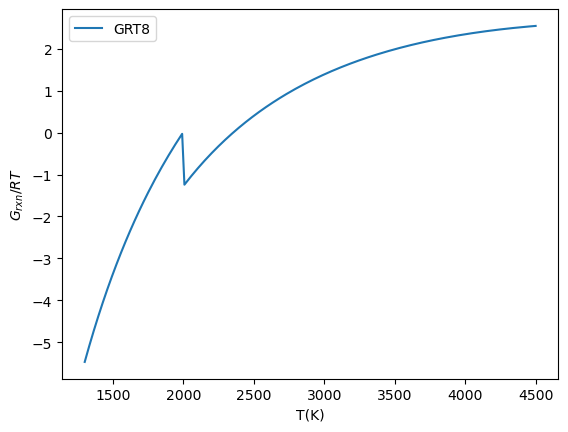

In [ ]:
#R8: COgas + 1/2O2,gas = CO2,gas
#G for reaction 8 at standard state of 1 bar and pure at T
G8=GgasCO2-GgasCO-0.5*GgasO2
logK8=-G8/(Rgas*TK*log_to_ln)
GRT8=np.zeros(num)
for i in range(0,TKlength):
    GRT8[i]=G8[i]/(Rgas*TK[i])
#plt.plot(TK,GRT8,label = 'GRT8')
#plt.ylabel('$G_{rxn}/RT$')
#plt.xlabel('T(K)')
#plt.legend()
#plt.show()

In [79]:
#R9: CH4,gas + 1/2O2,gas = 2H2,gas + COgas
#G for reaction at standard state of 1 bar, pure, and T
G9=2.0*GgasH2+GgasCO-GgasCH4-0.5*GgasO2
logK9=-G9/(Rgas*TK*log_to_ln)
GRT9=np.zeros(num)
for i in range(0,TKlength):
    GRT9[i]=G9[i]/(Rgas*TK[i])

In [80]:
#R10: H2,gas + 1/2O2,gas = H2Ogas
G10=GgasH2O-0.5*GgasO2-GgasH2
logK10=-G10/(Rgas*TK*log_to_ln)
GRT10=np.zeros(num)
for i in range(0,TKlength):
    GRT10[i]=G10[i]/(Rgas*TK[i])

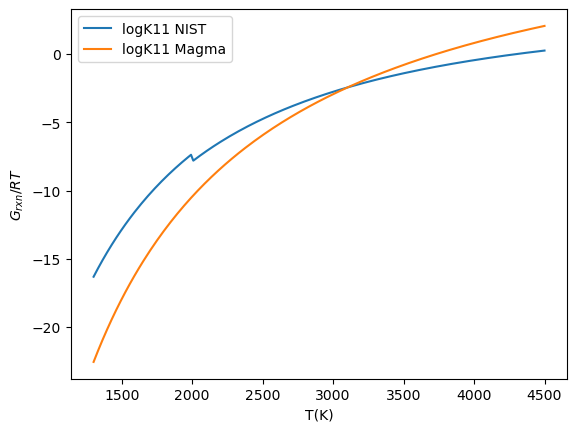

In [83]:
#R11:  FeO = Fegas + 1/2O2,gas
G11=0.5*GgasO2+GgasFe-GmeltFeO
logK11=-G11/(Rgas*TK*log_to_ln)
logK11magma=12.06-44992.0/TK  #Magma code version for comparison
GRT11=np.zeros(num)
for i in range(0,TKlength):
    GRT11[i]=G11[i]/(Rgas*TK[i])
plt.plot(TK,logK11,label = 'logK11 NIST')
plt.plot(TK,logK11magma,label = 'logK11 Magma')
plt.ylabel('$G_{rxn}/RT$')
plt.xlabel('T(K)')
plt.legend()
plt.show()

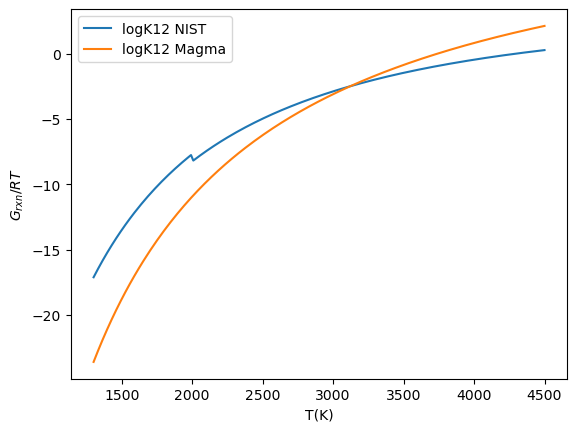

In [84]:
#R12: MgO = Mg,gas + 1/2O2,gas
G12=0.5*GgasO2+GgasMg-GmeltMgO
logK12=-G12/(Rgas*TK*log_to_ln)
logK12magma=12.56-46992/TK  #Magma code version for comparison
GRT12=np.zeros(num)
for i in range(0,TKlength):
    GRT12[i]=G12[i]/(Rgas*TK[i])
plt.plot(TK,logK12,label = 'logK12 NIST')
plt.plot(TK,logK12magma,label = 'logK12 Magma')
plt.ylabel('$G_{rxn}/RT$')
plt.xlabel('T(K)')
plt.legend()
plt.show()

In [85]:
#R13: SiO2 = SiO,gas +1/2O2
G13=0.5*GgasO2+GgasSiO-GmeltSiO2
logK13=-G13/(Rgas*TK*log_to_ln)
GRT13=np.zeros(num)
for i in range(0,num-1):
    GRT13[i]=G13[i]/(Rgas*TK[i])

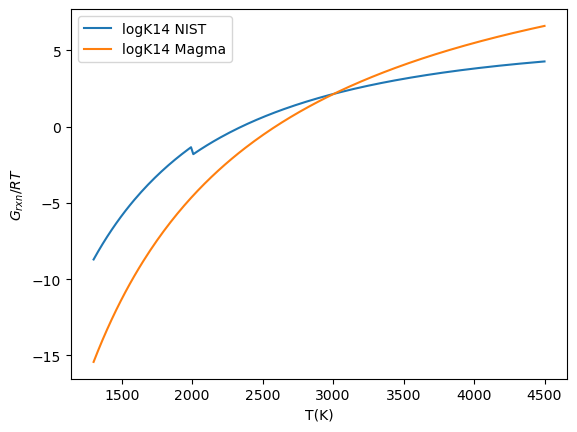

In [86]:
#REACTION 14: Na2O = 2Na gas + 1/2O2
G14=0.5*GgasO2+2.0*GgasNa-GmeltNa2O
logK14=-G14/(Rgas*TK*log_to_ln)
logK14magma=-(-15.56+40286.0/TK) #Magma code version for comparison
GRT14=np.zeros(num)
for i in range(0,num-1):
    GRT14=G14/(Rgas*TK)
plt.plot(TK,logK14,label = 'logK14 NIST')
plt.plot(TK,logK14magma,label = 'logK14 Magma')
plt.ylabel('$G_{rxn}/RT$')
plt.xlabel('T(K)')
plt.legend()
plt.show()

In [87]:
#REACTION 15: H2,gas = H2,silicate
# from Hirschmann et al. (2012) for the reaction H2 gas = H2 melt, no T dependence given
#lnk=-12.5-0.76*1.0e-4  #lnk for a standard state of 1 bar, or 1e-4 GPa
#G15=-Rgas*TK*lnk   #Delta G of the Hirschmann reaction at 1 bar
G15=GmeltH2-GgasH2  #Self consistent with above
logK15=-G15/(Rgas*TK*log_to_ln)   #at 1 bar
GRT15=np.zeros(num)
for i in range(0,TKlength):
    GRT15[i]=G15[i]/(Rgas*TK[i])


In [88]:
#REACTION 16: H2Ogas = H2Osilicate
#G16 = -Rgas*TK*(2565.0/TK -14.21)  #Rxn G for H2O vapor = H2O melt from Moore et al. (1998)
G16=GmeltH2O-GgasH2O  #Self consistent with above
logK16=-G16/(Rgas*TK*log_to_ln)
#G16prov=GmeltH2O-GgasH2O  #Using extracted melt H2O thermodynamic data with NIST H2Ogas data
#logK16prov=-G16/(Rgas*TK*log_to_ln)
GRT16=np.zeros(num)
for i in range(0,TKlength):
    GRT16[i]=G16[i]/(Rgas*TK[i])

In [89]:
#REACTION 17: COgas = CO melt
# data are scarce, so we use Table 2 of Hirschmann (2016, Am Min) to suggest
# that CO solubility is about 1/3 that of CO2 (see below for G18)
G18=5200.0-TK*(-119.77)
logK18=-G18/(Rgas*TK*log_to_ln)
logK17=logK18-log(3.0)
G17=-Rgas*TK*log_to_ln*logK17
GRT17=np.zeros(num)
for i in range(0,TKlength):
    GRT17[i]=G17[i]/(Rgas*TK[i])

In [90]:
#REACTION 18: CO2,gas = CO2,melt
# Hrxn CO2 gas = CO2 melt = 5200 J/mole (Pan et al., 1991) at 1473K
# lnK for this reaction at 1473K = -14.83 (Pan et al., 1991)
# Grxn =-R*1473K*lnk = 181626.027 J/mole
# Grxn=5200-T*Srxn, solve for Srxn = -119.77 J/mole
# Grxn = 5200 -T*(-119.77)
G18=5200.0-TK*(-119.77)
logK18=-G18/(Rgas*TK*log_to_ln)
GRT18=np.zeros(num)
for i in range(0,TKlength):
    GRT18[i]=G18[i]/(Rgas*TK[i])

In [91]:
#REACTION 19: SiO + 2H2 = SiH4 + 1/2O2 in vapor phase
G19=0.5*GgasO2 + GgasSiH4 -2.0*GgasH2 - GgasSiO  #Self consistent with above
logK19=-G19/(Rgas*TK*log_to_ln)   #at 1 bar
GRT19=np.zeros(num)
for i in range(0,TKlength):
    GRT19[i]=G19[i]/(Rgas*TK[i])